In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , AdaBoostClassifier , BaggingClassifier , ExtraTreesClassifier, VotingClassifier , StackingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import RUSBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score,f1_score,precision_score,recall_score,roc_auc_score,roc_curve
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Student_performance_data _.csv')  # Load your dataset here

In [3]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [4]:
df.tail()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0
2391,3392,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,2392.0,2196.500000,690.655244,1001.000000,1598.750000,2196.500000,2794.250000,3392.000000
Age,2392.0,16.468645,1.123798,15.000000,15.000000,16.000000,17.000000,18.000000
Gender,2392.0,0.510870,0.499986,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2392.0,0.877508,1.028476,0.000000,0.000000,0.000000,2.000000,3.000000
ParentalEducation,2392.0,1.746237,1.000411,0.000000,1.000000,2.000000,2.000000,4.000000
StudyTimeWeekly,2392.0,9.771992,5.652774,0.001057,5.043079,9.705363,14.408410,19.978094
Absences,2392.0,14.541388,8.467417,0.000000,7.000000,15.000000,22.000000,29.000000
Tutoring,2392.0,0.301421,0.458971,0.000000,0.000000,0.000000,1.000000,1.000000
ParentalSupport,2392.0,2.122074,1.122813,0.000000,1.000000,2.000000,3.000000,4.000000
Extracurricular,2392.0,0.383361,0.486307,0.000000,0.000000,0.000000,1.000000,1.000000


In [7]:
df.shape

(2392, 15)

In [8]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

In [9]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

In [10]:
df.isna().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## Visualization

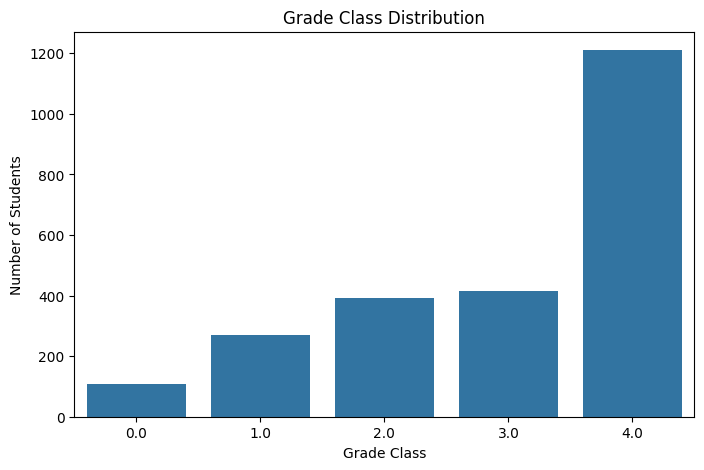

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GradeClass')
plt.title('Grade Class Distribution')
plt.xlabel('Grade Class')
plt.ylabel('Number of Students')
plt.show()

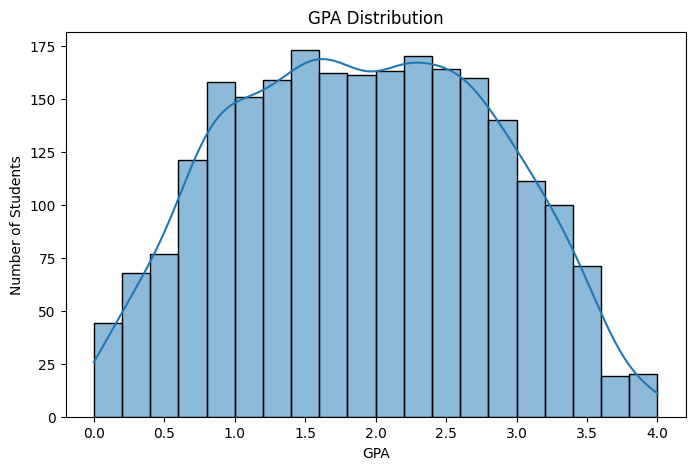

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='GPA', bins=20, kde=True)
plt.title('GPA Distribution')
plt.xlabel('GPA')
plt.ylabel('Number of Students')
plt.show()

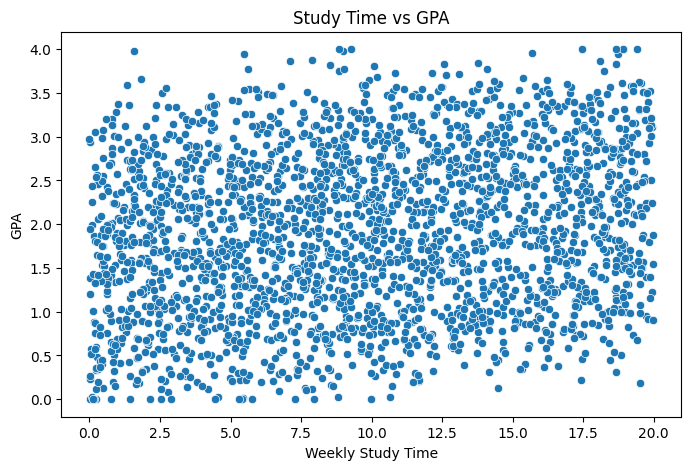

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='StudyTimeWeekly', y='GPA')
plt.title('Study Time vs GPA')
plt.xlabel('Weekly Study Time')
plt.ylabel('GPA')
plt.show()

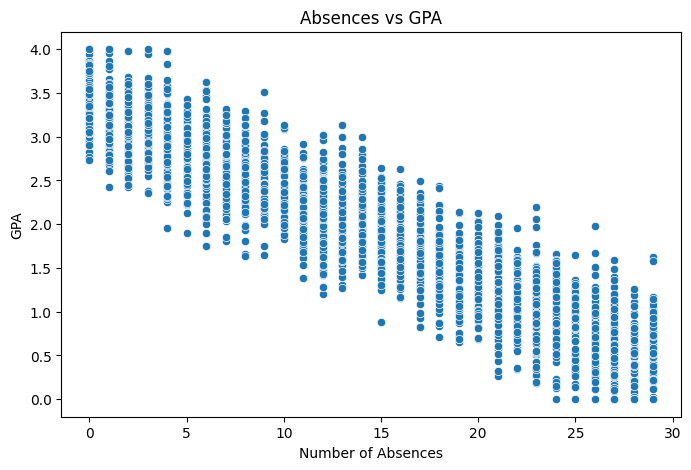

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Absences', y='GPA')
plt.title('Absences vs GPA')
plt.xlabel('Number of Absences')
plt.ylabel('GPA')
plt.show()

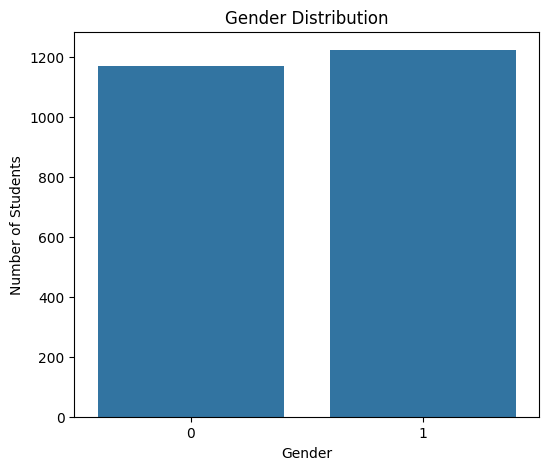

In [16]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.show()

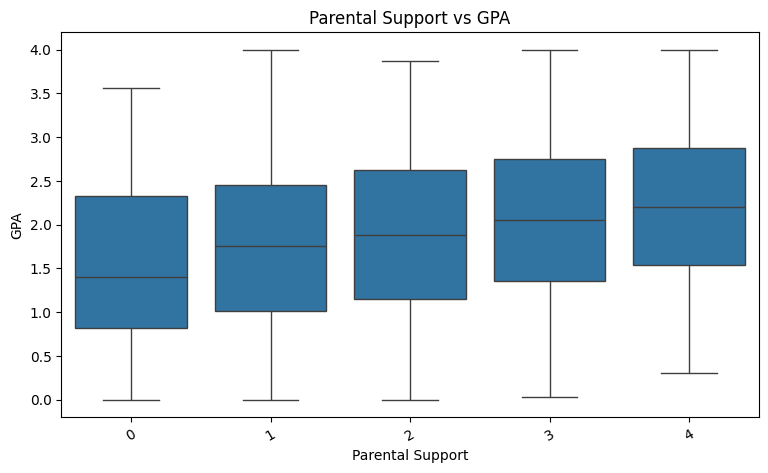

In [17]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='ParentalSupport', y='GPA')
plt.title('Parental Support vs GPA')
plt.xlabel('Parental Support')
plt.ylabel('GPA')
plt.xticks(rotation=30)
plt.show()

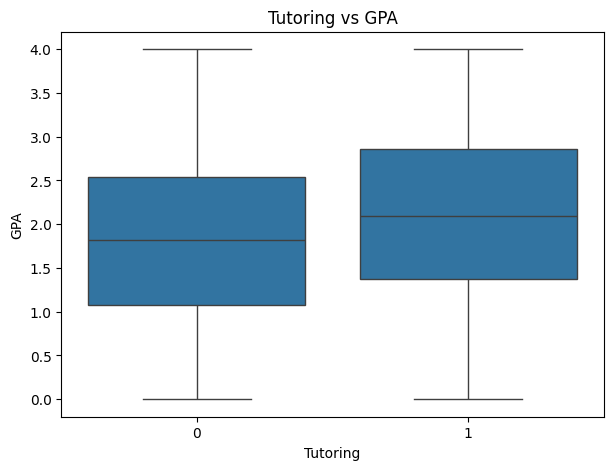

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Tutoring', y='GPA')
plt.title('Tutoring vs GPA')
plt.xlabel('Tutoring')
plt.ylabel('GPA')
plt.show()

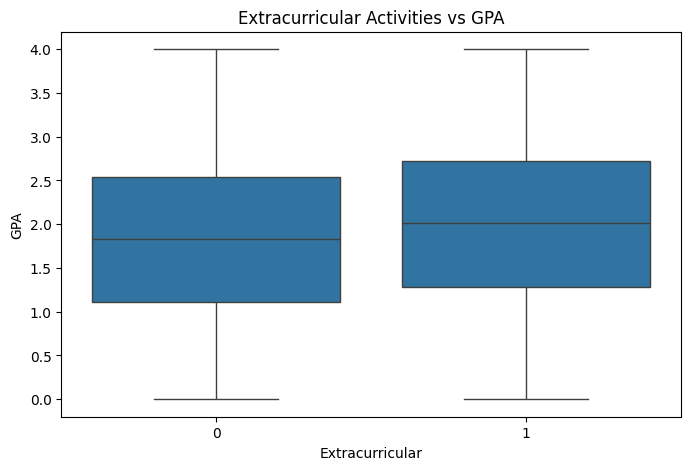

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Extracurricular', y='GPA')
plt.title('Extracurricular Activities vs GPA')
plt.xlabel('Extracurricular')
plt.ylabel('GPA')
plt.show()

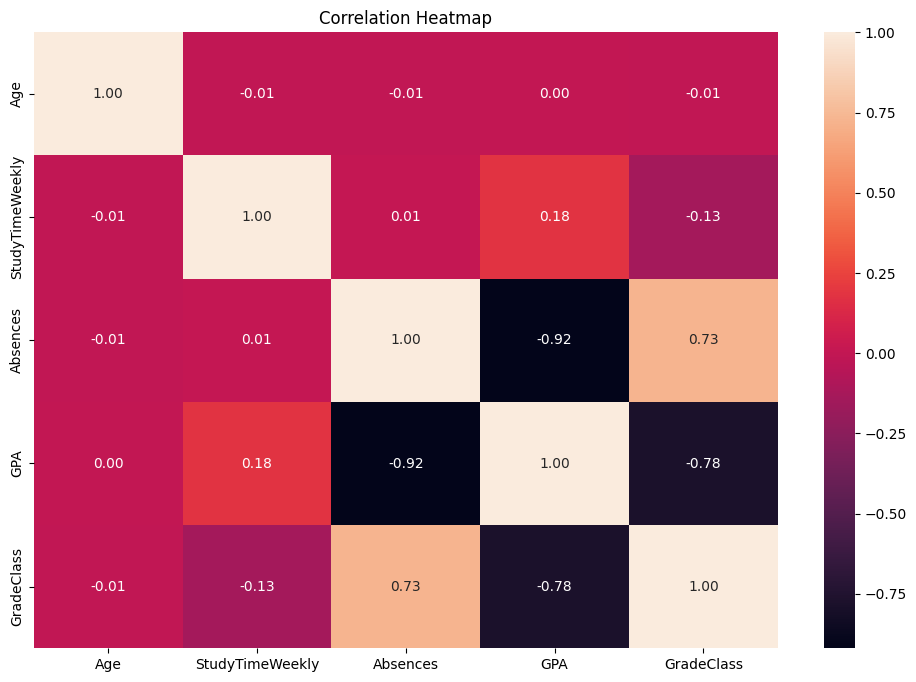

In [20]:
plt.figure(figsize=(12,8))

numeric_cols = [
    'Age',
    'StudyTimeWeekly',
    'Absences',
    'GPA',
    'GradeClass'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr,annot=True,cmap='rocket',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

## Dataset Spliting

In [21]:
x = df.drop(['GradeClass'],axis = 1)
y = df['GradeClass']

## Train Test Split Apply

In [22]:
xtrain , xtest, ytrain , ytest = train_test_split(x,y, test_size = .75,random_state = 42)

## `Performing Random Forest ` 

In [23]:
rf = RandomForestClassifier()
rf.fit(xtrain,ytrain)

print("Training Score : ", rf.score(xtrain,ytrain)*100)
print("Testing Score : ", rf.score(xtest,ytest)*100)

# Prediction 

y_pred_rf = rf.predict(xtest)
print("Predict successfully ")


Training Score :  100.0
Testing Score :  91.36008918617614
Predict successfully 


## `Random  Forest` Model Evaluation

Accuracy Score for Random Forest  :  91.36008918617614


Random Forest Classifier
              precision    recall  f1-score   support

         0.0       0.83      0.38      0.52        77
         1.0       0.82      0.84      0.83       197
         2.0       0.93      0.90      0.92       295
         3.0       0.87      0.92      0.89       306
         4.0       0.95      0.98      0.96       919

    accuracy                           0.91      1794
   macro avg       0.88      0.80      0.82      1794
weighted avg       0.91      0.91      0.91      1794



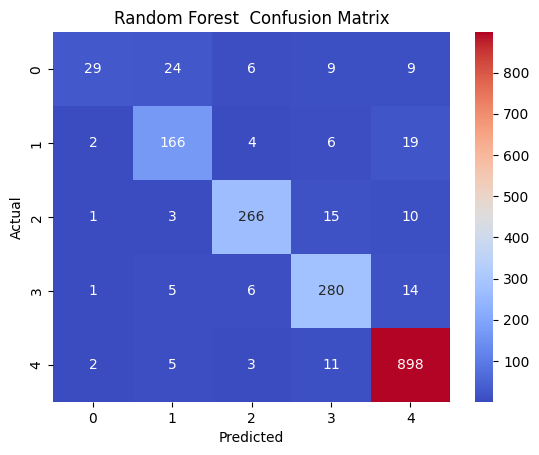

F1 Score for Random Forest :  90.8794897582267
Sensitivity for Random Forest :  91.36008918617614
Specificity for Random Forest :  96.00787486039927
NPV for Random Forest         :  97.77724005561532
FPR for Random Forest         :  3.992125139600738
FNR for Random Forest         :  8.639910813823857
ROC-AUC Score for Random Forest :  0.9868468332401683


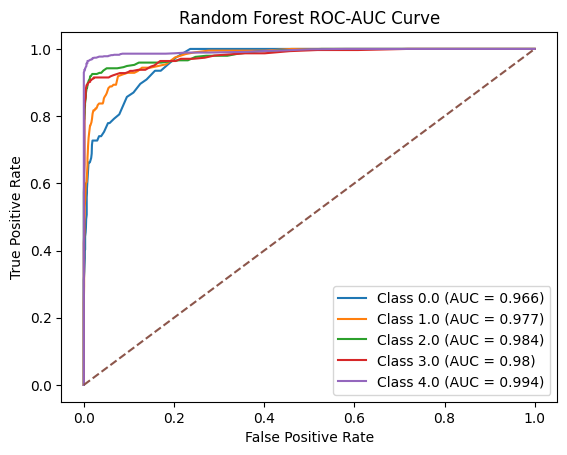

In [24]:
## Accuracy Score 
ac = accuracy_score(ytest , y_pred_rf)
print("Accuracy Score for Random Forest  : ", ac *100)
print('\n')


#classification report
cr = classification_report(ytest,y_pred_rf)
print("Random Forest Classifier")
print(cr)


# Confusion Matrix
cm = confusion_matrix(ytest,y_pred_rf)
sns.heatmap(cm , annot = True  ,cmap='coolwarm', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest  Confusion Matrix")
plt.show()



#F1 Score
f1_rf = f1_score(ytest, y_pred_rf,average='weighted')
print("F1 Score for Random Forest : ", f1_rf*100)


# Sensitivity
sensitivity_rf = recall_score(ytest,y_pred_rf, average='weighted')
print("Sensitivity for Random Forest : ", sensitivity_rf * 100)


# Classes
classes = np.unique(ytest)

# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []

classes = np.unique(ytest)

for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)

    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_rf = np.average(specificity_list,weights=weights)
npv_rf = np.average(npv_list,weights=weights)
fpr_rf = np.average(fpr_list,weights=weights)
fnr_rf = np.average( fnr_list, weights=weights)


print("Specificity for Random Forest : ", specificity_rf * 100)
print("NPV for Random Forest         : ", npv_rf * 100)
print("FPR for Random Forest         : ", fpr_rf * 100)
print("FNR for Random Forest         : ", fnr_rf * 100)



# ROC-AUC
# ==============================

y_prob_rf = rf.predict_proba(xtest)
roc_auc_rf = roc_auc_score(ytest,y_prob_rf,multi_class='ovr',average='weighted')
print("ROC-AUC Score for Random Forest : ", roc_auc_rf)




# ROC-AUC Curve
# ==============================

from sklearn.preprocessing import label_binarize

ytest_bin = label_binarize(ytest,classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve( ytest_bin[:, i], y_prob_rf[:, i])

    auc_class = roc_auc_score( ytest_bin[:, i], y_prob_rf[:, i])

    plt.plot(fpr_curve,tpr_curve,label="Class " + str(classes[i]) + " (AUC = " + str(round(auc_class, 3)) + ")")


plt.plot([0, 1],[0, 1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC-AUC Curve")

plt.legend()

plt.show()

## `Performing  Decision Tree `

In [25]:
dt = DecisionTreeClassifier()
dt.fit(xtrain,ytrain)

print("Training Score : ", dt.score(xtrain,ytrain)*100)
print("Testing Score : ", dt.score(xtest,ytest)*100)

# Prediction 

y_pred_dt = dt.predict(xtest)
print("Predict successfully ")


Training Score :  100.0
Testing Score :  92.69788182831661
Predict successfully 


## `Decision Tree` evaluation

Accuracy Score :  92.69788182831661


Decision Tree Classifier
              precision    recall  f1-score   support

         0.0       0.70      0.75      0.72        77
         1.0       0.85      0.86      0.85       197
         2.0       0.90      0.92      0.91       295
         3.0       0.90      0.91      0.90       306
         4.0       0.98      0.97      0.97       919

    accuracy                           0.93      1794
   macro avg       0.87      0.88      0.87      1794
weighted avg       0.93      0.93      0.93      1794





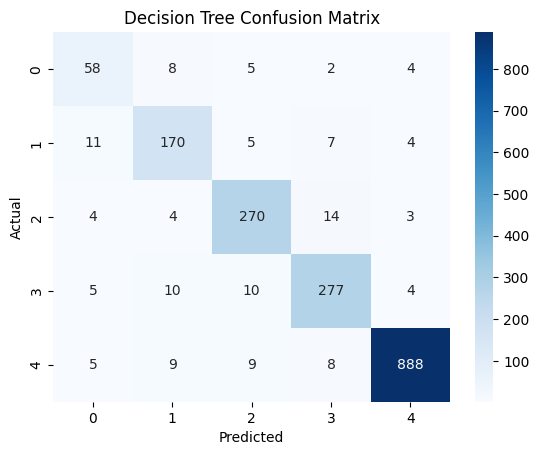

F1 Score For Decision Tree Classifier :  92.76443809850856


Specificity for Random Forest :  98.17270844945385
NPV for Random Forest         :  97.37608297358294
FPR for Random Forest         :  1.8272915505461476
FNR for Random Forest         :  7.3021181716833885
ROC-AUC Score for Decision Tree :  0.9543529513888523


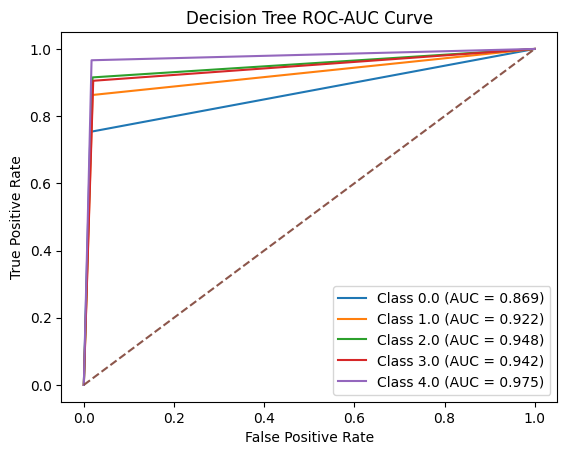

In [26]:
#Accuracy_score 
ac = accuracy_score(ytest , y_pred_dt)
print("Accuracy Score : ", ac *100)
print('\n')

#Classification Report
cr = classification_report(ytest,y_pred_dt)
print("Decision Tree Classifier")
print(cr)
print('\n')


# confusin matrix
cm = confusion_matrix(ytest,y_pred_dt)
sns.heatmap(cm , annot = True , cmap = 'Blues', fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()



#F1 Score
f1 = f1_score(ytest , y_pred_dt,average='weighted')
print("F1 Score For Decision Tree Classifier : ", f1 *100)
print('\n')


# Classes
classes = np.unique(ytest)

# Specificity, NPV, FPR, FNR


specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []

classes = np.unique(ytest)

for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)

    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average
weights = cm.sum(axis=1)

specificity_rf = np.average(specificity_list,weights=weights)
npv_rf = np.average(npv_list,weights=weights)
fpr_rf = np.average(fpr_list,weights=weights)
fnr_rf = np.average( fnr_list, weights=weights)


print("Specificity for Random Forest : ", specificity_rf * 100)
print("NPV for Random Forest         : ", npv_rf * 100)
print("FPR for Random Forest         : ", fpr_rf * 100)
print("FNR for Random Forest         : ", fnr_rf * 100)



# ROC-AUC
y_prob_dt = dt.predict_proba(xtest)
roc_auc_dt = roc_auc_score(ytest,y_prob_dt,multi_class='ovr',average='weighted')
print("ROC-AUC Score for Decision Tree : ", roc_auc_dt)


# ROC-AUC Curve


ytest_bin = label_binarize(ytest,classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve( ytest_bin[:, i], y_prob_dt[:, i])

    auc_class = roc_auc_score( ytest_bin[:, i], y_prob_dt[:, i])

    plt.plot(fpr_curve,tpr_curve,label="Class " + str(classes[i]) + " (AUC = " + str(round(auc_class, 3)) + ")")


plt.plot([0, 1],[0, 1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC-AUC Curve")

plt.legend()

plt.show()


# `Performing XGBoost Classifier`

In [27]:
from xgboost import XGBClassifier

# XGBoost Model
xgb = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)

# Training
xgb.fit(xtrain, ytrain)

# Scores
print("Training Score : ", xgb.score(xtrain, ytrain) * 100)
print("Testing Score : ", xgb.score(xtest, ytest) * 100)

# Prediction
y_pred_xgb = xgb.predict(xtest)
print("Predict successfully")

Training Score :  100.0
Testing Score :  91.69453734671126
Predict successfully


# `XGBoost Classifier`  Model Evaluation

Accuracy Score :  91.69453734671126


XGBoost Classifier
              precision    recall  f1-score   support

         0.0       0.68      0.60      0.63        77
         1.0       0.83      0.88      0.86       197
         2.0       0.92      0.93      0.92       295
         3.0       0.87      0.90      0.88       306
         4.0       0.97      0.95      0.96       919

    accuracy                           0.92      1794
   macro avg       0.85      0.85      0.85      1794
weighted avg       0.92      0.92      0.92      1794





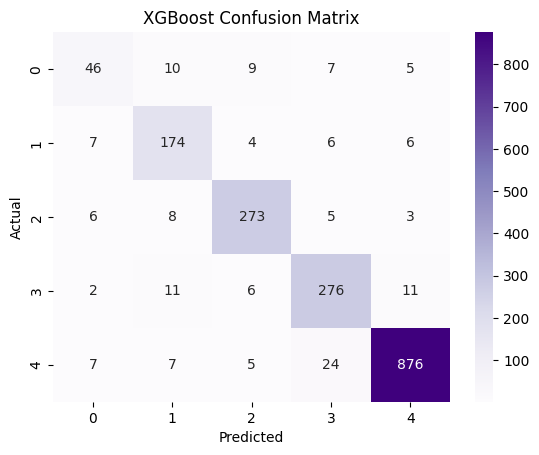

F1 Score For XGBoost Classifier :  91.67955292724639
Specificity for XGBoost :  97.48914049666844
NPV for XGBoost         :  96.70845844943182
FPR for XGBoost         :  2.5108595033315693
FNR for XGBoost         :  8.30546265328874
ROC-AUC Score for XGBoost :  0.9928259894506506


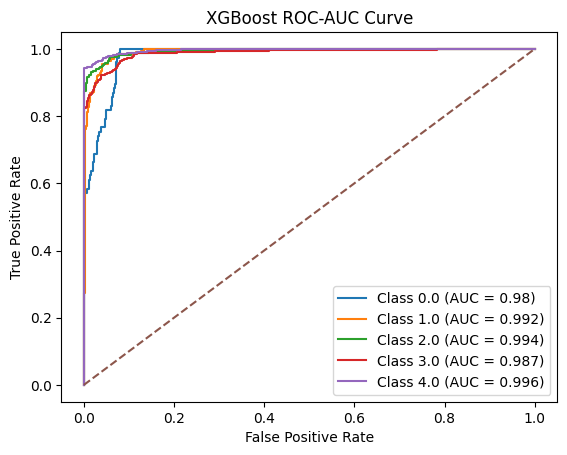

In [28]:
#Accuracy_score 
ac = accuracy_score(ytest , y_pred_xgb)
print("Accuracy Score : ", ac *100)
print('\n')

#Classification Report
cr = classification_report(ytest,y_pred_xgb)
print("XGBoost Classifier")
print(cr)
print('\n')


# confusin matrix
cm = confusion_matrix(ytest,y_pred_xgb)
sns.heatmap(cm , annot = True , cmap = 'Purples', fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


#F1 Score
f1 = f1_score(ytest , y_pred_xgb,average='weighted')
print("F1 Score For XGBoost Classifier : ", f1 *100)


# Classes
classes = np.unique(ytest)

# Specificity, NPV, FPR, FNR


specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []

classes = np.unique(ytest)

for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)

    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average
weights = cm.sum(axis=1)

specificity_xgb = np.average(specificity_list,weights=weights)
npv_xgb = np.average(npv_list,weights=weights)
fpr_xgb = np.average(fpr_list,weights=weights)
fnr_xgb = np.average( fnr_list, weights=weights)


print("Specificity for XGBoost : ", specificity_xgb * 100)
print("NPV for XGBoost         : ", npv_xgb * 100)
print("FPR for XGBoost         : ", fpr_xgb * 100)
print("FNR for XGBoost         : ", fnr_xgb * 100)



# ROC-AUC
y_prob_xgb = xgb.predict_proba(xtest)
roc_auc_xgb = roc_auc_score(ytest,y_prob_xgb,multi_class='ovr',average='weighted')
print("ROC-AUC Score for XGBoost : ", roc_auc_xgb)


# ROC-AUC Curve


ytest_bin = label_binarize(ytest,classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve( ytest_bin[:, i], y_prob_xgb[:, i])

    auc_class = roc_auc_score( ytest_bin[:, i], y_prob_xgb[:, i])

    plt.plot(fpr_curve,tpr_curve,label="Class " + str(classes[i]) + " (AUC = " + str(round(auc_class, 3)) + ")")


plt.plot([0, 1],[0, 1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC-AUC Curve")

plt.legend()

plt.show()


# `Performing SVM `

In [29]:
svm = SVC(kernel='linear',probability=True, random_state=42)


# Training
svm.fit(xtrain, ytrain) 
print("Training Score : ", svm.score(xtrain, ytrain) * 100)

print("Testing Score : ", svm.score(xtest, ytest) * 100)

# Prediction
y_pred_svm = svm.predict(xtest)


Training Score :  80.93645484949833
Testing Score :  79.15273132664437


# `SVM` Model Evaluation

Accuracy Score :  79.15273132664437
              precision    recall  f1-score   support

         0.0       0.20      0.18      0.19        77
         1.0       0.61      0.65      0.63       197
         2.0       0.67      0.65      0.66       295
         3.0       0.73      0.67      0.70       306
         4.0       0.93      0.96      0.95       919

    accuracy                           0.79      1794
   macro avg       0.63      0.62      0.62      1794
weighted avg       0.79      0.79      0.79      1794



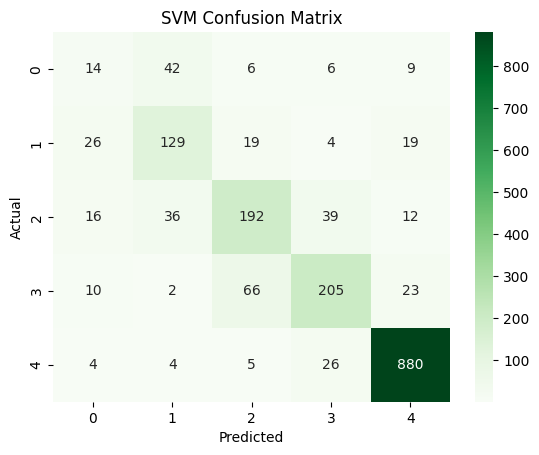

F1 Score For SVM Classifier :  78.91252834276669


Specificity for SVM :  93.68131171714829
NPV for SVM         :  94.76071938880516
FPR for SVM         :  6.318688282851717
FNR for SVM         :  20.84726867335563
ROC-AUC Score for SVM :  0.9286319137918547


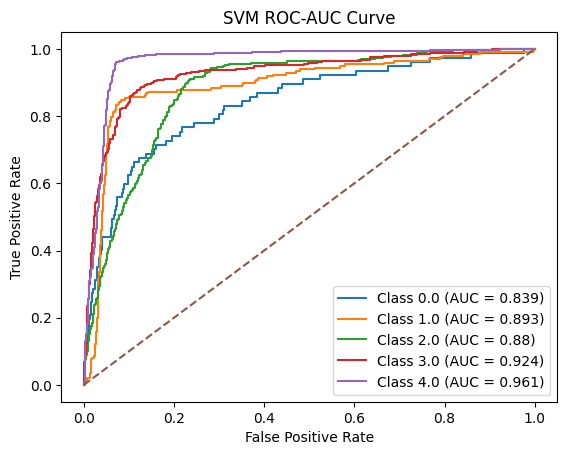

In [30]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_svm)
print("Accuracy Score : ", ac * 100)


# Classification Report
cr = classification_report(ytest, y_pred_svm)
print(cr)


# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_svm)

sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()


# F1 Score
f1 = f1_score(ytest, y_pred_svm, average='weighted')

print("F1 Score For SVM Classifier : ", f1 * 100)
print("\n")


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_svm = np.average(specificity_list, weights=weights)

npv_svm = np.average(npv_list, weights=weights)

fpr_svm = np.average(fpr_list, weights=weights)

fnr_svm = np.average(fnr_list, weights=weights)


print("Specificity for SVM : ", specificity_svm * 100)
print("NPV for SVM         : ", npv_svm * 100)
print("FPR for SVM         : ", fpr_svm * 100)
print("FNR for SVM         : ", fnr_svm * 100)


# ROC-AUC

y_prob_svm = svm.predict_proba(xtest)

roc_auc_svm = roc_auc_score(
    ytest,
    y_prob_svm,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for SVM : ", roc_auc_svm)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("SVM ROC-AUC Curve")

plt.legend()

plt.show()

# `Performing Gradient Boosting Classifier `

In [31]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gb.fit(xtrain, ytrain)

# Training
print("Training Score : ", gb.score(xtrain, ytrain) * 100)

# Testing
print("Testing Score : ", gb.score(xtest, ytest) * 100)

#prediction
y_pred_gb = gb.predict(xtest)

Training Score :  100.0
Testing Score :  92.47491638795987


# `Gradient Boosting Classifier ` Model Evaluation

Accuracy Score :  92.47491638795987
              precision    recall  f1-score   support

         0.0       0.62      0.71      0.67        77
         1.0       0.87      0.84      0.86       197
         2.0       0.89      0.92      0.90       295
         3.0       0.91      0.91      0.91       306
         4.0       0.98      0.97      0.97       919

    accuracy                           0.92      1794
   macro avg       0.86      0.87      0.86      1794
weighted avg       0.93      0.92      0.93      1794



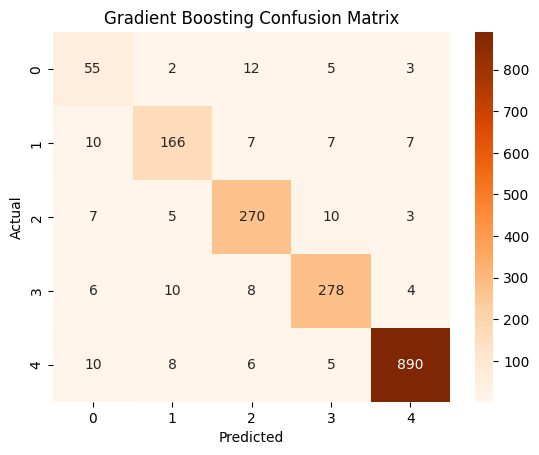

F1 Score For Gradient Boosting Classifier :  92.5636647308117


Specificity for Gradient Boosting :  98.07885060249839
NPV for Gradient Boosting :  97.46101097197946
FPR for Gradient Boosting :  1.9211493975016019
FNR for Gradient Boosting :  7.5250836120401345
ROC-AUC Score for Gradient Boosting :  0.9901804065224904


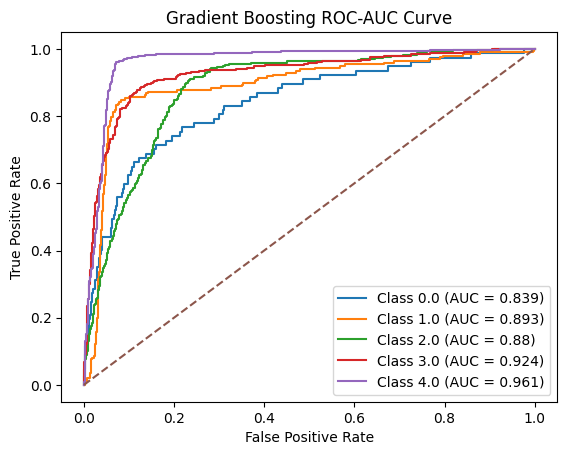

In [32]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_gb)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_gb)
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_gb)
sns.heatmap(cm, annot=True, cmap='Oranges', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(ytest, y_pred_gb, average='weighted')

print("F1 Score For Gradient Boosting Classifier : ", f1 * 100)
print("\n")


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_gb = np.average(specificity_list, weights=weights)

npv_gb = np.average(npv_list, weights=weights)

fpr_gb  = np.average(fpr_list, weights=weights)

fnr_gb = np.average(fnr_list, weights=weights)


print("Specificity for Gradient Boosting : ", specificity_gb * 100)
print("NPV for Gradient Boosting : ", npv_gb * 100)
print("FPR for Gradient Boosting : ", fpr_gb * 100)
print("FNR for Gradient Boosting : ", fnr_gb * 100)


# ROC-AUC

y_prob_gb = gb.predict_proba(xtest)

roc_auc_gb = roc_auc_score(
    ytest,
    y_prob_gb,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Gradient Boosting : ", roc_auc_gb)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Gradient Boosting ROC-AUC Curve")

plt.legend()

plt.show()

# `Performing AdaBoostClassifier`

In [33]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

ada.fit(xtrain, ytrain)

#Training 
print("Training Score : ", ada.score(xtrain, ytrain) * 100)
#Testing 
print("Testing Score : ", ada.score(xtest, ytest) * 100)

#prediction
y_pred_ada = ada.predict(xtest)

Training Score :  91.47157190635451
Testing Score :  93.1438127090301


# `Performing AdaBoostClassifier` Model Evaluation

Accuracy Score :  93.1438127090301
              precision    recall  f1-score   support

         0.0       0.90      0.68      0.77        77
         1.0       0.94      0.85      0.90       197
         2.0       0.94      0.92      0.93       295
         3.0       0.89      0.92      0.90       306
         4.0       0.94      0.98      0.96       919

    accuracy                           0.93      1794
   macro avg       0.92      0.87      0.89      1794
weighted avg       0.93      0.93      0.93      1794



F1 Score For AdaBoost Classifier :  93.01315144020549
Specificity for AdaBoost :  95.96687488897643
NPV for AdaBoost :  98.0647964795216
FPR for AdaBoost :  4.033125111023569
FNR for AdaBoost :  6.856187290969899
ROC-AUC Score for AdaBoost :  0.9704810843638858


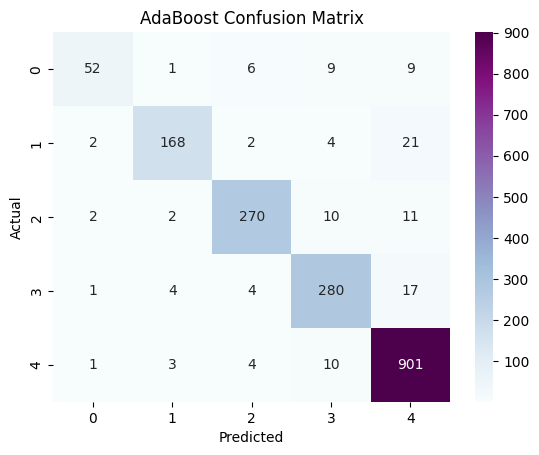

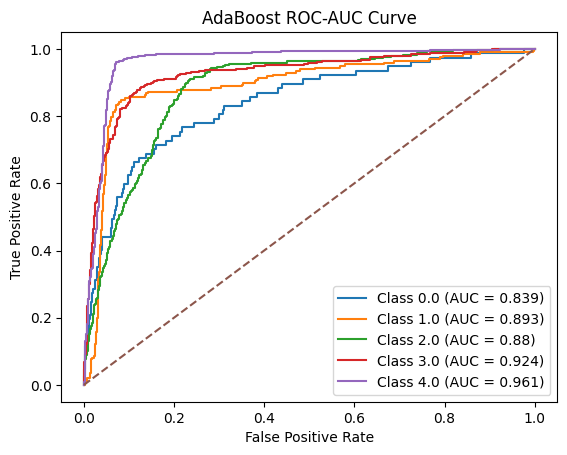

In [34]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_ada)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_ada)   
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_ada)
sns.heatmap(cm, annot=True, cmap='BuPu', fmt='d')
plt.xlabel("Predicted")     
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")
print("\n")

# F1 Score
f1 = f1_score(ytest, y_pred_ada, average='weighted')
print("F1 Score For AdaBoost Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_ada = np.average(specificity_list, weights=weights)

npv_ada = np.average(npv_list, weights=weights)

fpr_ada   = np.average(fpr_list, weights=weights)

fnr_ada = np.average(fnr_list, weights=weights)


print("Specificity for AdaBoost : ", specificity_ada * 100)
print("NPV for AdaBoost : ", npv_ada * 100)
print("FPR for AdaBoost : ", fpr_ada * 100)
print("FNR for AdaBoost : ", fnr_ada * 100)


# ROC-AUC

y_prob_ada = ada.predict_proba(xtest)

roc_auc_ada = roc_auc_score(
    ytest,
    y_prob_ada  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for AdaBoost : ", roc_auc_ada)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("AdaBoost ROC-AUC Curve")

plt.legend()

plt.show()

## `Performing Bagging Classifier`

In [35]:
bc = BaggingClassifier(n_estimators=100, random_state=42)

bc.fit(xtrain, ytrain)

#training
print("Training Score : ", bc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", bc.score(xtest, ytest) * 100)

#prediction
y_pred_bc = bc.predict(xtest)

Training Score :  100.0
Testing Score :  92.86510590858417


## `Performing Bagging Classifier` Model Evaluation 

Accuracy Score :  92.86510590858417
              precision    recall  f1-score   support

         0.0       0.67      0.71      0.69        77
         1.0       0.86      0.86      0.86       197
         2.0       0.91      0.93      0.92       295
         3.0       0.90      0.91      0.90       306
         4.0       0.98      0.97      0.98       919

    accuracy                           0.93      1794
   macro avg       0.86      0.87      0.87      1794
weighted avg       0.93      0.93      0.93      1794



F1 Score For Bagging Classifier :  92.91385845810153
Specificity for Bagging :  98.15860833051995
NPV for Bagging :  97.61634765143693
FPR for Bagging :  1.8413916694800514
FNR for Bagging :  7.1348940914158305
ROC-AUC Score for AdaBoost :  0.9704810843638858


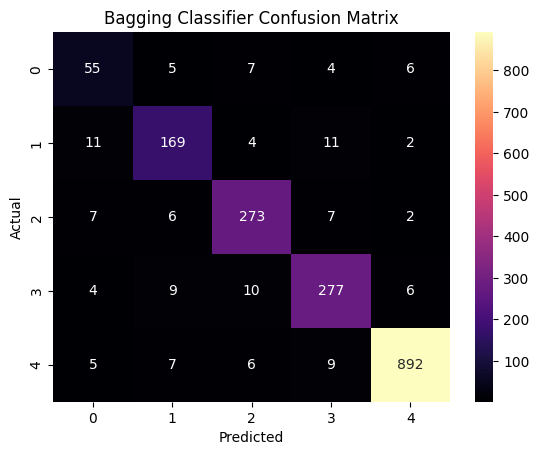

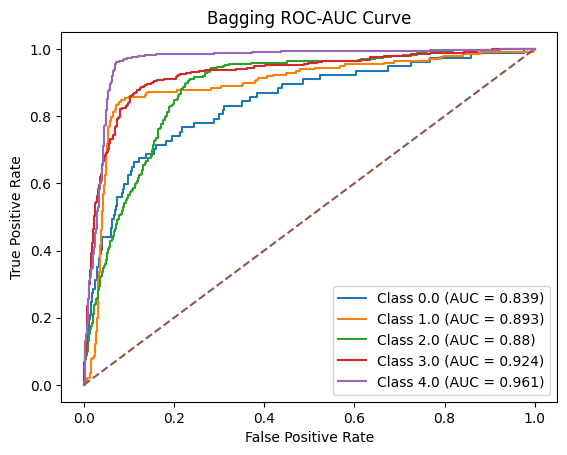

In [65]:
#accuracy score
ac = accuracy_score(ytest, y_pred_bc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_bc)
print(cr)
print("\n")


#confusion matrix
cm = confusion_matrix(ytest, y_pred_bc)
sns.heatmap(cm, annot=True, cmap='magma', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Classifier Confusion Matrix")

# F1 Score
f1 = f1_score(ytest, y_pred_bc, average='weighted')
print("F1 Score For Bagging Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_bc = np.average(specificity_list, weights=weights)

npv_bc = np.average(npv_list, weights=weights)

fpr_bc   = np.average(fpr_list, weights=weights)

fnr_bc = np.average(fnr_list, weights=weights)


print("Specificity for Bagging : ", specificity_bc * 100)
print("NPV for Bagging : ", npv_bc   * 100)
print("FPR for Bagging : ", fpr_bc * 100)
print("FNR for Bagging : ", fnr_bc * 100)


# ROC-AUC

y_prob_bc = bc.predict_proba(xtest)

roc_auc_bc = roc_auc_score(
    ytest,
    y_prob_ada  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for AdaBoost : ", roc_auc_ada)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Bagging ROC-AUC Curve")

plt.legend()

plt.show()

# `Performing ExtraTreesClassifier`

In [37]:
etc = ExtraTreesClassifier(n_estimators=100, random_state=42)

etc.fit(xtrain, ytrain)
#training
print("Training Score : ", etc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", etc.score(xtest, ytest) * 100)

#prediction
y_pred_etc = etc.predict(xtest)

Training Score :  100.0
Testing Score :  84.00222965440356


# `Extra Tree Classifier` Model Evaluation

Accuracy Score :  84.00222965440356
              precision    recall  f1-score   support

         0.0       0.74      0.40      0.52        77
         1.0       0.73      0.69      0.71       197
         2.0       0.78      0.77      0.78       295
         3.0       0.76      0.74      0.75       306
         4.0       0.91      0.97      0.94       919

    accuracy                           0.84      1794
   macro avg       0.78      0.71      0.74      1794
weighted avg       0.83      0.84      0.83      1794



F1 Score For Extra Trees Classifier :  83.4604472988368
Specificity for Extra Trees :  92.78424295746002
NPV for Extra Trees :  95.85611512710018
FPR for Extra Trees :  7.215757042539981
FNR for Extra Trees :  15.997770345596432
ROC-AUC Score for Extra Trees :  0.9637401155641828


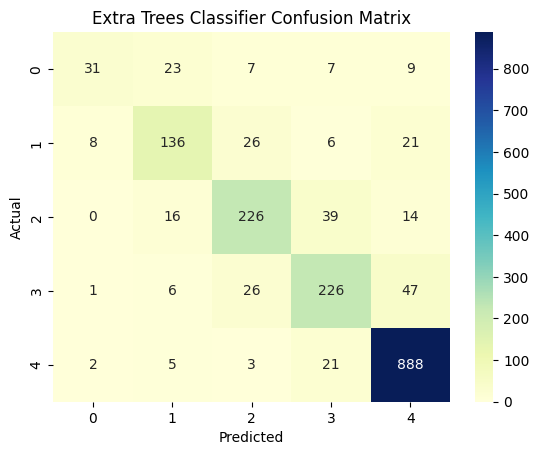

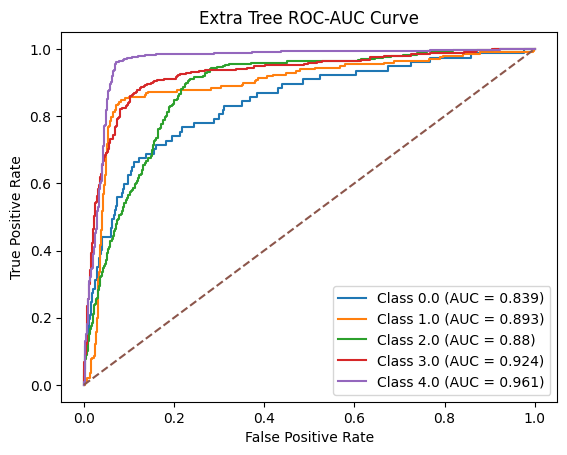

In [38]:
#accuracy score
ac = accuracy_score(ytest, y_pred_etc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_etc)
print(cr)
print("\n")


#confusion matrix
cm = confusion_matrix(ytest, y_pred_etc)
sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees Classifier Confusion Matrix")

# F1 Score
f1 = f1_score(ytest, y_pred_etc, average='weighted')
print("F1 Score For Extra Trees Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_etc = np.average(specificity_list, weights=weights)

npv_etc = np.average(npv_list, weights=weights)

fpr_etc   = np.average(fpr_list, weights=weights)

fnr_etc = np.average(fnr_list, weights=weights)


print("Specificity for Extra Trees : ", specificity_etc * 100)
print("NPV for Extra Trees : ", npv_etc   * 100)
print("FPR for Extra Trees : ", fpr_etc * 100)
print("FNR for Extra Trees : ", fnr_etc * 100)


# ROC-AUC

y_prob_etc = etc.predict_proba(xtest)

roc_auc_etc = roc_auc_score(
    ytest,
    y_prob_etc  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Extra Trees : ", roc_auc_etc)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Extra Tree ROC-AUC Curve")

plt.legend()

plt.show()

## `Performing VotingClassifier`

In [39]:
vt = VotingClassifier(estimators=[('rf', rf), ('dt', dt), ('xgb', xgb), ('svm', svm), ('gb', gb), ('ada', ada), ('bc', bc), ('etc', etc)], voting='soft')

vt.fit(xtrain, ytrain)

#training
print("Training Score : ", vt.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", vt.score(xtest, ytest) * 100)

#prediction
y_pred_vt = vt.predict(xtest)

Training Score :  100.0
Testing Score :  93.19955406911929


Accuracy Score :  93.19955406911929
              precision    recall  f1-score   support

         0.0       0.82      0.69      0.75        77
         1.0       0.89      0.86      0.87       197
         2.0       0.92      0.92      0.92       295
         3.0       0.92      0.91      0.91       306
         4.0       0.96      0.98      0.97       919

    accuracy                           0.93      1794
   macro avg       0.90      0.87      0.88      1794
weighted avg       0.93      0.93      0.93      1794

F1 Score For Voting Classifier :  93.10252341004023
Specificity for Voting Classifier :  96.88690206192837
NPV for Voting Classifier :  98.03512630955714
FPR for Voting Classifier :  3.11309793807163
FNR for Voting Classifier :  6.800445930880714
ROC-AUC Score for Voting Classifier :  0.9891802076675114


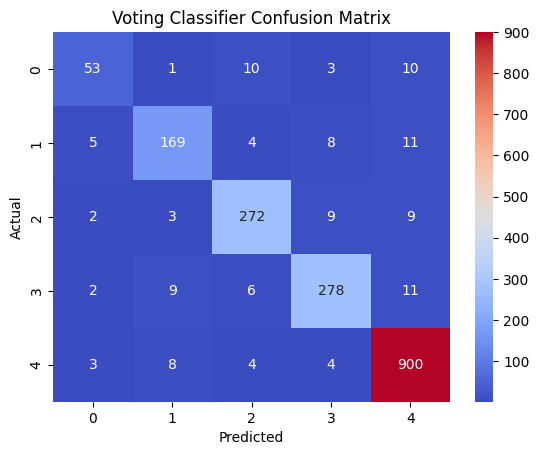

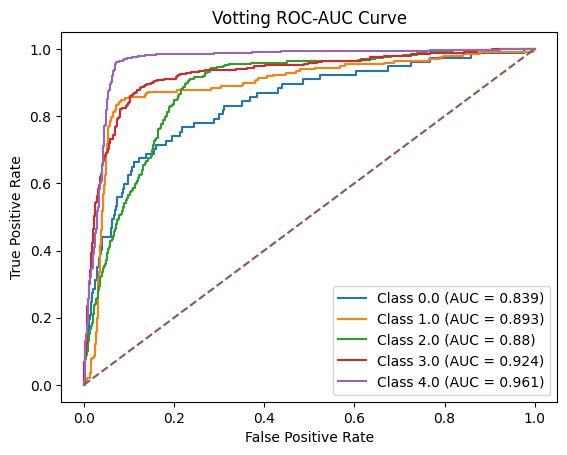

In [40]:
#accuracy score
ac = accuracy_score(ytest, y_pred_vt)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_vt)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_vt)
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Classifier Confusion Matrix")

# F1 Score
f1 = f1_score(ytest, y_pred_vt, average='weighted')
print("F1 Score For Voting Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_vt = np.average(specificity_list, weights=weights)

npv_vt = np.average(npv_list, weights=weights)

fpr_vt   = np.average(fpr_list, weights=weights)

fnr_vt = np.average(fnr_list, weights=weights)


print("Specificity for Voting Classifier : ", specificity_vt * 100)
print("NPV for Voting Classifier : ", npv_vt   * 100)
print("FPR for Voting Classifier : ", fpr_vt * 100)
print("FNR for Voting Classifier : ", fnr_vt * 100)


# ROC-AUC

y_prob_vt = vt.predict_proba(xtest)

roc_auc_vt = roc_auc_score(
    ytest,
    y_prob_vt  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Voting Classifier : ", roc_auc_vt)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Votting ROC-AUC Curve")

plt.legend()

plt.show()

## `Performing Catboost Classifier`

In [41]:
# CatBoost Classifier
cat = CatBoostClassifier(
    iterations=100,
    random_state=42,
    verbose=0
)

cat.fit(xtrain, ytrain)

# Training
print("Training Score : ", cat.score(xtrain, ytrain) * 100)

# Testing
print("Testing Score : ", cat.score(xtest, ytest) * 100)

# Prediction
y_pred_cat = cat.predict(xtest)


Training Score :  100.0
Testing Score :  92.97658862876254


# `CatBoost` Model Evaluation


Accuracy Score :  92.97658862876254
              precision    recall  f1-score   support

         0.0       0.78      0.74      0.76        77
         1.0       0.88      0.86      0.87       197
         2.0       0.89      0.91      0.90       295
         3.0       0.88      0.92      0.90       306
         4.0       0.98      0.97      0.98       919

    accuracy                           0.93      1794
   macro avg       0.88      0.88      0.88      1794
weighted avg       0.93      0.93      0.93      1794



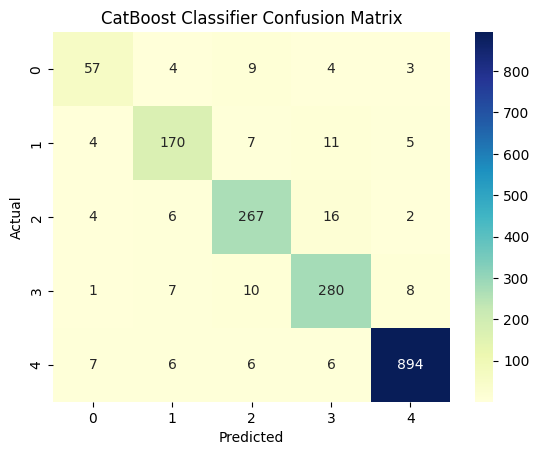

F1 Score For CatBoost Classifier :  92.97322152727526
Specificity for CatBoost Classifier :  97.97289460259748
NPV for CatBoost Classifier :  97.70470690935667
FPR for CatBoost Classifier :  2.0271053974025355
FNR for CatBoost Classifier :  7.023411371237458
ROC-AUC Score for CatBoost Classifier :  0.9940789228962967


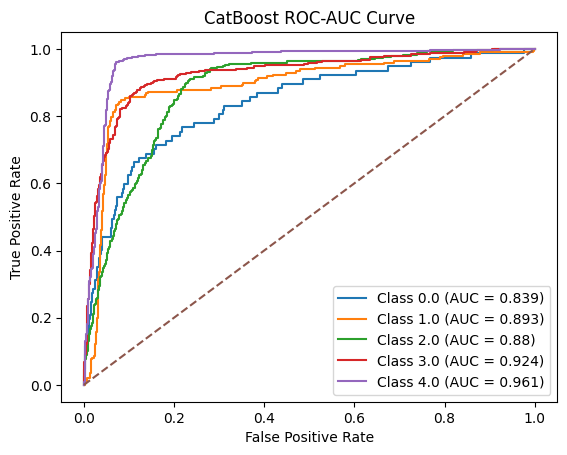

In [42]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_cat)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_cat)
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_cat)

sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Classifier Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(ytest, y_pred_cat, average='weighted')
print("F1 Score For CatBoost Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_cat = np.average(specificity_list, weights=weights)

npv_cat = np.average(npv_list, weights=weights)

fpr_cat   = np.average(fpr_list, weights=weights)

fnr_cat = np.average(fnr_list, weights=weights)


print("Specificity for CatBoost Classifier : ", specificity_cat * 100)
print("NPV for CatBoost Classifier : ", npv_cat   * 100)
print("FPR for CatBoost Classifier : ", fpr_cat * 100)
print("FNR for CatBoost Classifier : ", fnr_cat * 100)


# ROC-AUC

y_prob_cat = cat.predict_proba(xtest)

roc_auc_cat = roc_auc_score(
    ytest,
    y_prob_cat  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for CatBoost Classifier : ", roc_auc_cat)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("CatBoost ROC-AUC Curve")

plt.legend()

plt.show()

## `Performing LightGBM classifier`

In [43]:
# LightGBM Classifier

lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbosity=-1
)

# Training
lgbm.fit(xtrain, ytrain)

# Training Score
print("Training Score : ", lgbm.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score : ", lgbm.score(xtest, ytest) * 100)

# Prediction
y_pred_lgbm = lgbm.predict(xtest)


Training Score :  100.0
Testing Score :  91.58305462653288


# `LightGBM` Model Evaluation

Accuracy Score :  91.58305462653288
              precision    recall  f1-score   support

         0.0       0.70      0.61      0.65        77
         1.0       0.84      0.86      0.85       197
         2.0       0.93      0.91      0.92       295
         3.0       0.88      0.85      0.87       306
         4.0       0.95      0.98      0.96       919

    accuracy                           0.92      1794
   macro avg       0.86      0.84      0.85      1794
weighted avg       0.91      0.92      0.91      1794



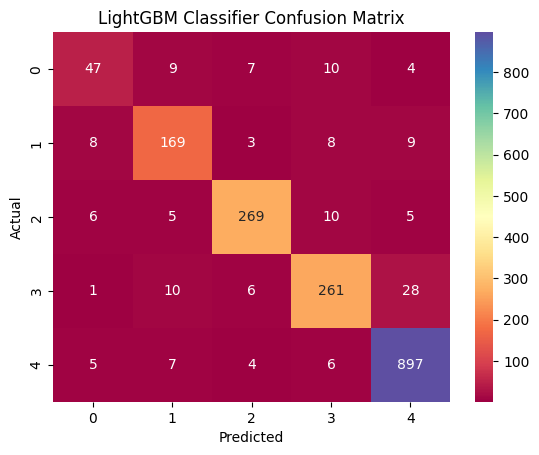

F1 Score For LightGBM Classifier :  91.4696647801678
Specificity for LightGBM Classifier :  96.43467146314653
NPV for LightGBM Classifier :  97.6121260954097
FPR for LightGBM Classifier :  3.5653285368534604
FNR for LightGBM Classifier :  8.416945373467112
ROC-AUC Score for CatBoost Classifier :  0.9940789228962967


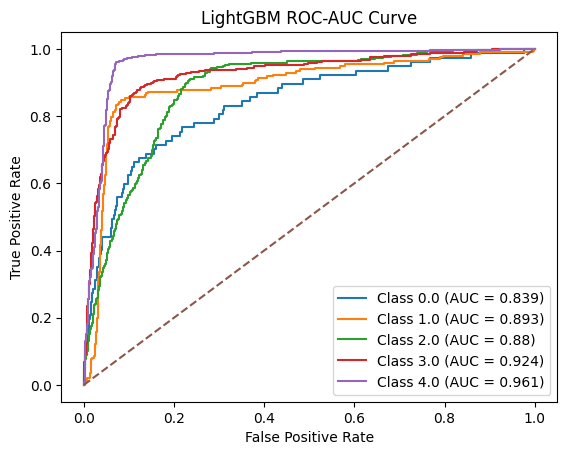

In [44]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_lgbm)
print("Accuracy Score : ", ac * 100)

# Classification Report
print(classification_report(ytest, y_pred_lgbm))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_lgbm)

sns.heatmap(cm, annot=True, cmap='Spectral', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Classifier Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(ytest, y_pred_lgbm, average='weighted')
print("F1 Score For LightGBM Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_lgbm = np.average(specificity_list, weights=weights)

npv_lgbm = np.average(npv_list, weights=weights)

fpr_lgbm   = np.average(fpr_list, weights=weights)

fnr_lgbm = np.average(fnr_list, weights=weights)


print("Specificity for LightGBM Classifier : ", specificity_lgbm * 100)
print("NPV for LightGBM Classifier : ", npv_lgbm   * 100)
print("FPR for LightGBM Classifier : ", fpr_lgbm * 100)
print("FNR for LightGBM Classifier : ", fnr_lgbm * 100)


# ROC-AUC

y_prob_lgbm = lgbm.predict_proba(xtest)

roc_auc_lgbm = roc_auc_score(
    ytest,
    y_prob_lgbm  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for CatBoost Classifier : ", roc_auc_cat)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("LightGBM ROC-AUC Curve")

plt.legend()

plt.show()  

## Performing HistGradientBoosting Classifier

In [45]:
# HistGradientBoosting Classifier
hgb = HistGradientBoostingClassifier(max_iter=100,random_state=42)
# Training
hgb.fit(xtrain, ytrain)

# Training Score
print("Training Score : ", hgb.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score : ", hgb.score(xtest, ytest) * 100)

# Prediction
y_pred_hgb = hgb.predict(xtest)

Training Score :  100.0
Testing Score :  91.36008918617614


Accuracy Score :  91.36008918617614
              precision    recall  f1-score   support

         0.0       0.58      0.57      0.58        77
         1.0       0.83      0.78      0.80       197
         2.0       0.91      0.91      0.91       295
         3.0       0.88      0.91      0.89       306
         4.0       0.97      0.97      0.97       919

    accuracy                           0.91      1794
   macro avg       0.83      0.83      0.83      1794
weighted avg       0.91      0.91      0.91      1794



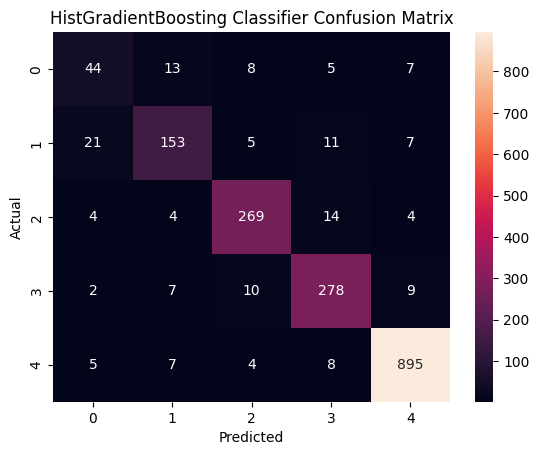

F1 Score For HistGradientBoosting Classifier :  91.31131513506774
Specificity for HistGradientBoosting Classifier :  97.3943768665536
NPV for HistGradientBoosting Classifier :  97.59901574511505
FPR for HistGradientBoosting Classifier :  2.6056231334464086
FNR for HistGradientBoosting Classifier :  8.639910813823857
ROC-AUC Score for HistGradientBoosting Classifier :  0.9922153291631431


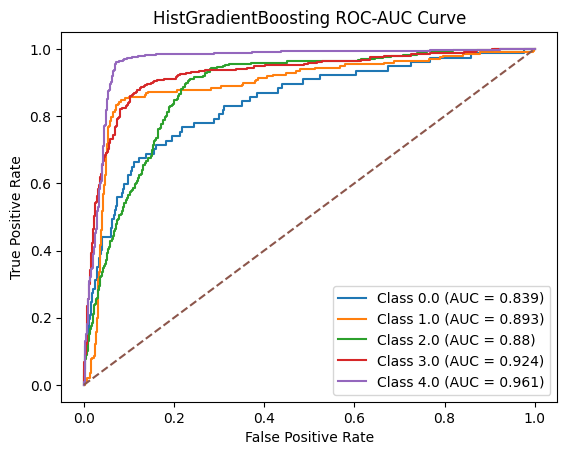

In [46]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_hgb)
print("Accuracy Score : ", ac * 100)

# Classification Report
print(classification_report(ytest, y_pred_hgb))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_hgb)

sns.heatmap(cm, annot=True, cmap='rocket', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HistGradientBoosting Classifier Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(ytest, y_pred_hgb, average='weighted')
print("F1 Score For HistGradientBoosting Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_hgb = np.average(specificity_list, weights=weights)

npv_hgb = np.average(npv_list, weights=weights)

fpr_hgb    = np.average(fpr_list, weights=weights)

fnr_hgb = np.average(fnr_list, weights=weights)


print("Specificity for HistGradientBoosting Classifier : ", specificity_hgb * 100)
print("NPV for HistGradientBoosting Classifier : ", npv_hgb   * 100)
print("FPR for HistGradientBoosting Classifier : ", fpr_hgb * 100)
print("FNR for HistGradientBoosting Classifier : ", fnr_hgb * 100)


# ROC-AUC

y_prob_hgb = hgb.predict_proba(xtest)

roc_auc_hgb = roc_auc_score(
    ytest,
    y_prob_hgb  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for HistGradientBoosting Classifier : ", roc_auc_hgb)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("HistGradientBoosting ROC-AUC Curve")

plt.legend()

plt.show()

## Performing Naive BayesClassifier

In [53]:
# Naive Bayes
nb = GaussianNB()

# Training
nb.fit(xtrain, ytrain)

# Training Score
print("Training Score : ", nb.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score : ", nb.score(xtest, ytest) * 100)

# Prediction
y_pred_nb = nb.predict(xtest)

Training Score :  76.92307692307693
Testing Score :  75.13935340022296


Accuracy Score :  75.13935340022296
              precision    recall  f1-score   support

         0.0       0.56      0.06      0.12        77
         1.0       0.57      0.70      0.63       197
         2.0       0.61      0.65      0.63       295
         3.0       0.57      0.66      0.61       306
         4.0       0.93      0.88      0.91       919

    accuracy                           0.75      1794
   macro avg       0.65      0.59      0.58      1794
weighted avg       0.76      0.75      0.75      1794



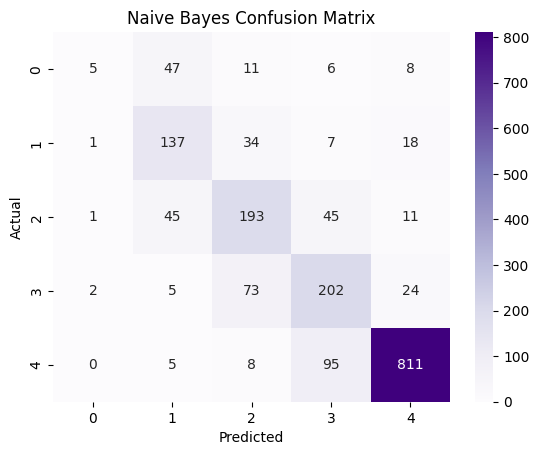

F1 Score For Naive Bayes Classifier :  74.55521232230949
Specificity for Naive Bayes Classifier :  92.58141617587955
NPV for Naive Bayes Classifier :  91.03282517080888
FPR for Naive Bayes Classifier :  7.41858382412045
FNR for Naive Bayes Classifier :  24.860646599777034
ROC-AUC Score for Naive Bayes Classifier :  0.9229888935299957


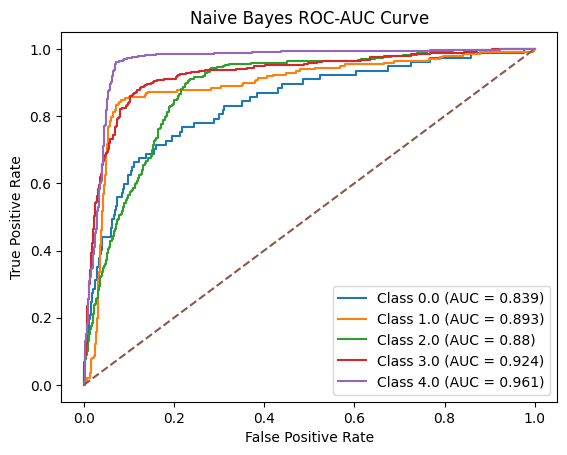

In [54]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_nb)
print("Accuracy Score : ", ac * 100)

# Classification Report
print(classification_report(ytest, y_pred_nb))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_nb)

sns.heatmap(cm, annot=True, cmap='Purples', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()


# F1 Score
f1 = f1_score(ytest, y_pred_nb, average='weighted')
print("F1 Score For Naive Bayes Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_nb = np.average(specificity_list, weights=weights)

npv_nb = np.average(npv_list, weights=weights)

fpr_nb    = np.average(fpr_list, weights=weights)

fnr_nb = np.average(fnr_list, weights=weights)


print("Specificity for Naive Bayes Classifier : ", specificity_nb * 100)
print("NPV for Naive Bayes Classifier : ", npv_nb   * 100)
print("FPR for Naive Bayes Classifier : ", fpr_nb * 100)
print("FNR for Naive Bayes Classifier : ", fnr_nb * 100)


# ROC-AUC

y_prob_nb = nb.predict_proba(xtest)

roc_auc_nb = roc_auc_score(
    ytest,
    y_prob_nb  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Naive Bayes Classifier : ", roc_auc_nb)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Naive Bayes ROC-AUC Curve")

plt.legend()

plt.show()

## Performing LDA Classifier

In [55]:
# LDA
lda = LinearDiscriminantAnalysis()

# Parameters
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen']
}

# Parameter Tuning
grid = GridSearchCV(
    lda,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters : ", grid.best_params_)

# Best Model
lda = grid.best_estimator_

# Training Score
print("Training Score : ", lda.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score : ", lda.score(xtest, ytest) * 100)

# Prediction
y_pred_lda = lda.predict(xtest)

Best Parameters :  {'solver': 'svd'}
Training Score :  74.08026755852842
Testing Score :  70.51282051282051


Accuracy Score :  70.51282051282051
              precision    recall  f1-score   support

         0.0       0.29      0.10      0.15        77
         1.0       0.52      0.50      0.51       197
         2.0       0.46      0.51      0.48       295
         3.0       0.51      0.52      0.51       306
         4.0       0.90      0.93      0.92       919

    accuracy                           0.71      1794
   macro avg       0.54      0.51      0.51      1794
weighted avg       0.69      0.71      0.70      1794



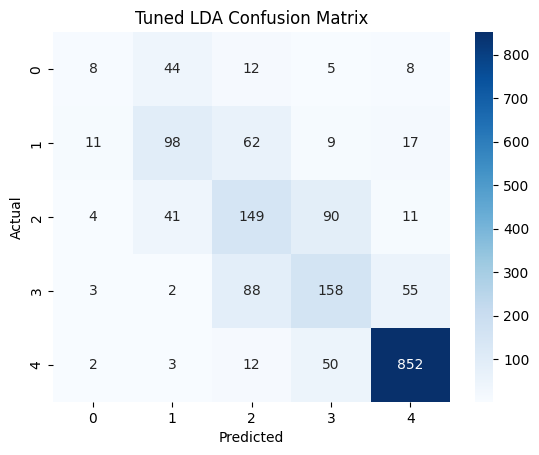

F1 Score For Tuned LDA Classifier :  69.7746774089065
Specificity for Tuned LDA Classifier :  90.32958957713133
NPV for Tuned LDA Classifier :  91.78683739485876
FPR for Tuned LDA Classifier :  9.670410422868665
FNR for Tuned LDA Classifier :  29.48717948717949
ROC-AUC Score for Tuned LDA Classifier :  0.9109153061933633


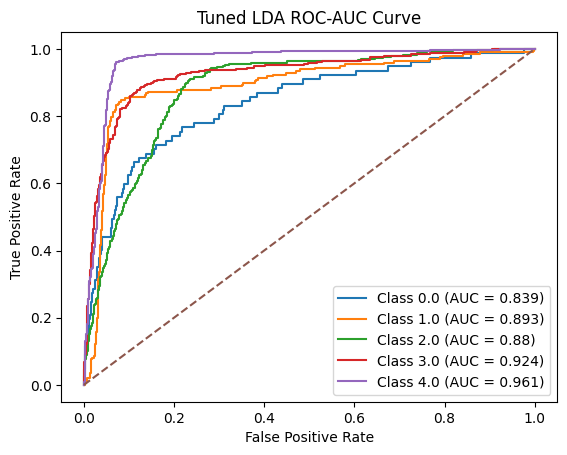

In [56]:
# Accuracy
ac = accuracy_score(ytest, y_pred_lda)
print("Accuracy Score : ", ac * 100)

# Classification Report
print(classification_report(ytest, y_pred_lda))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_lda)

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned LDA Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(ytest, y_pred_lda, average='weighted')
print("F1 Score For Tuned LDA Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_lda = np.average(specificity_list, weights=weights)

npv_lda = np.average(npv_list, weights=weights)

fpr_lda    = np.average(fpr_list, weights=weights)

fnr_lda = np.average(fnr_list, weights=weights)


print("Specificity for Tuned LDA Classifier : ", specificity_lda * 100)
print("NPV for Tuned LDA Classifier : ", npv_lda   * 100)
print("FPR for Tuned LDA Classifier : ", fpr_lda * 100)
print("FNR for Tuned LDA Classifier : ", fnr_lda * 100)


# ROC-AUC

y_prob_lda = lda.predict_proba(xtest)

roc_auc_lda = roc_auc_score(
    ytest,
    y_prob_lda  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Tuned LDA Classifier : ", roc_auc_lda)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Tuned LDA ROC-AUC Curve")

plt.legend()

plt.show()

## Performing QDA Classifier


In [58]:
# QDA
qda = QuadraticDiscriminantAnalysis()

# Parameters
param_grid = {
    'reg_param': [0.0, 0.01, 0.1, 0.5, 0.9, 1.0]
}

# Parameter Tuning
grid = GridSearchCV(
    qda,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters : ", grid.best_params_)

# Best Model
qda = grid.best_estimator_

# Training Score
print("Training Score : ", qda.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score : ", qda.score(xtest, ytest) * 100)

# Prediction
y_pred_qda = qda.predict(xtest)

Best Parameters :  {'reg_param': 0.5}
Training Score :  73.7458193979933
Testing Score :  68.61761426978819


Accuracy Score :  68.61761426978819
              precision    recall  f1-score   support

         0.0       0.26      0.21      0.23        77
         1.0       0.48      0.54      0.51       197
         2.0       0.49      0.48      0.49       295
         3.0       0.49      0.54      0.51       306
         4.0       0.91      0.87      0.89       919

    accuracy                           0.69      1794
   macro avg       0.53      0.53      0.53      1794
weighted avg       0.69      0.69      0.69      1794



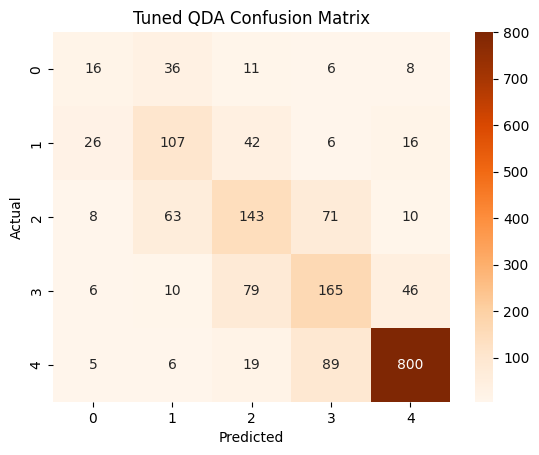

F1 Score For Tuned QDA Classifier :  68.90198874238727
Specificity for Tuned QDA Classifier :  90.7851543487235
NPV for Tuned QDA Classifier :  89.23376944785633
FPR for Tuned QDA Classifier :  9.214845651276498
FNR for Tuned QDA Classifier :  31.382385730211816
ROC-AUC Score for Tuned QDA Classifier :  0.9061198415625145


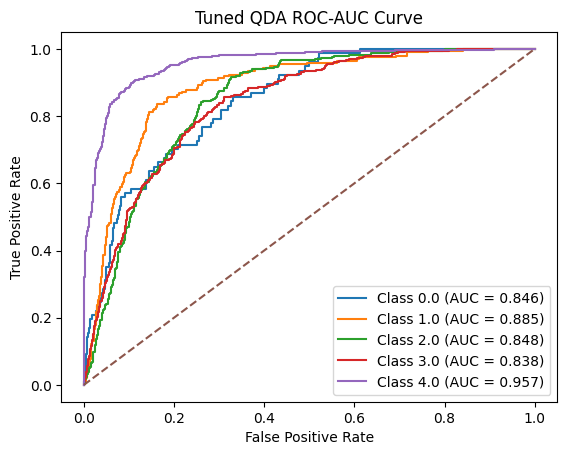

In [59]:
# Accuracy
ac = accuracy_score(ytest, y_pred_qda)
print("Accuracy Score : ", ac * 100)

# Classification Report
print(classification_report(ytest, y_pred_qda))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_qda)

sns.heatmap(cm, annot=True, cmap='Oranges', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned QDA Confusion Matrix")
plt.show()



# F1 Score
f1 = f1_score(ytest, y_pred_qda, average='weighted')
print("F1 Score For Tuned QDA Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_qda = np.average(specificity_list, weights=weights)

npv_qda = np.average(npv_list, weights=weights)

fpr_qda     = np.average(fpr_list, weights=weights)

fnr_qda = np.average(fnr_list, weights=weights)


print("Specificity for Tuned QDA Classifier : ", specificity_qda * 100)
print("NPV for Tuned QDA Classifier : ", npv_qda   * 100)
print("FPR for Tuned QDA Classifier : ", fpr_qda * 100)
print("FNR for Tuned QDA Classifier : ", fnr_qda * 100)


# ROC-AUC

y_prob_qda = qda.predict_proba(xtest)

roc_auc_qda = roc_auc_score(
    ytest,
    y_prob_qda  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Tuned QDA Classifier : ", roc_auc_qda)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_qda[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_qda[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Tuned QDA ROC-AUC Curve")

plt.legend()

plt.show()

## Performing Balance Random Forest Classifier

In [57]:
# Balanced Random Forest
brf = BalancedRandomForestClassifier(
    random_state=42
)

# Parameters
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Parameter Tuning
grid = GridSearchCV(
    brf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters : ", grid.best_params_)

# Best Model
brf = grid.best_estimator_

# Training Score
print("Training Score : ", brf.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score : ", brf.score(xtest, ytest) * 100)

# Prediction
y_pred_brf = brf.predict(xtest)

Best Parameters :  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
Training Score :  95.81939799331104
Testing Score :  91.19286510590858


Accuracy Score :  91.19286510590858
              precision    recall  f1-score   support

         0.0       0.62      0.74      0.67        77
         1.0       0.91      0.79      0.84       197
         2.0       0.95      0.90      0.92       295
         3.0       0.85      0.92      0.88       306
         4.0       0.95      0.96      0.96       919

    accuracy                           0.91      1794
   macro avg       0.86      0.86      0.85      1794
weighted avg       0.92      0.91      0.91      1794



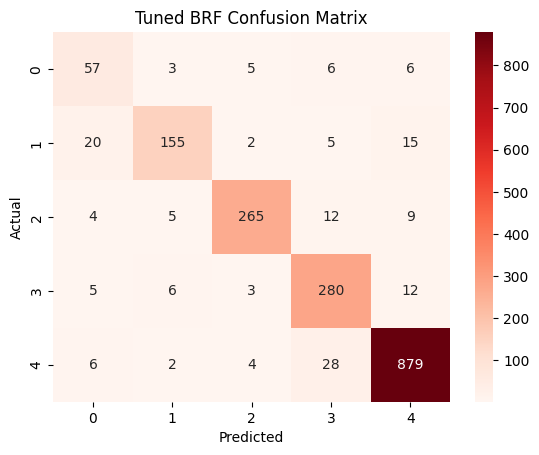

F1 Score For Tuned Balance Random Forest  Classifier :  91.2672368544677
Specificity for Tuned BRF Classifier :  96.60544190834497
NPV for Tuned BRF Classifier :  96.68951035453776
FPR for Tuned BRF Classifier :  3.3945580916550213
FNR for Tuned BRF Classifier :  8.807134894091416
ROC-AUC Score for Tuned BRF Classifier :  0.9805108539109789


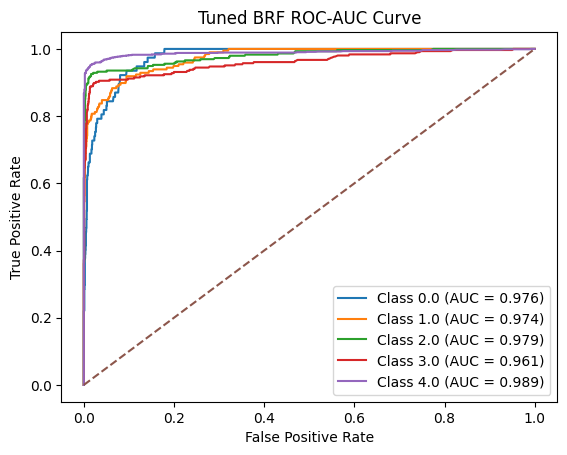

In [60]:
# Accuracy
ac = accuracy_score(ytest, y_pred_brf)
print("Accuracy Score : ", ac * 100)

# Classification Report
print(classification_report(ytest, y_pred_brf))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_brf)

sns.heatmap(cm, annot=True, cmap='Reds', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned BRF Confusion Matrix")
plt.show()



# F1 Score
f1 = f1_score(ytest, y_pred_brf, average='weighted')
print("F1 Score For Tuned Balance Random Forest  Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_brf = np.average(specificity_list, weights=weights)

npv_brf = np.average(npv_list, weights=weights)

fpr_brf     = np.average(fpr_list, weights=weights)

fnr_brf = np.average(fnr_list, weights=weights)


print("Specificity for Tuned BRF Classifier : ", specificity_brf * 100)
print("NPV for Tuned BRF Classifier : ", npv_brf   * 100)
print("FPR for Tuned BRF Classifier : ", fpr_brf * 100)
print("FNR for Tuned BRF Classifier : ", fnr_brf * 100)


# ROC-AUC

y_prob_brf = brf.predict_proba(xtest)

roc_auc_brf = roc_auc_score(
    ytest,
    y_prob_brf  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Tuned BRF Classifier : ", roc_auc_brf)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_brf[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_brf[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Tuned BRF ROC-AUC Curve")

plt.legend()

plt.show()

## Performing RusBoost Classifier

In [ ]:
# RUSBoost
rus = RUSBoostClassifier(
    random_state=42
)

# Parameters
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Parameter Tuning
grid = GridSearchCV(
    rus,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(xtrain, ytrain)

# Best Parameters
print("Best Parameters : ", grid.best_params_)

# Best Model
rus = grid.best_estimator_

# Training Score
print("Training Score : ", rus.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score : ", rus.score(xtest, ytest) * 100)

# Prediction
y_pred_rus = rus.predict(xtest)


Best Parameters :  {'learning_rate': 0.01, 'n_estimators': 50}
Training Score :  63.04347826086957
Testing Score :  65.94202898550725


Accuracy Score :  65.94202898550725
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        77
         1.0       0.00      0.00      0.00       197
         2.0       0.52      0.92      0.67       295
         3.0       0.00      0.00      0.00       306
         4.0       0.71      0.99      0.83       919

    accuracy                           0.66      1794
   macro avg       0.25      0.38      0.30      1794
weighted avg       0.45      0.66      0.54      1794



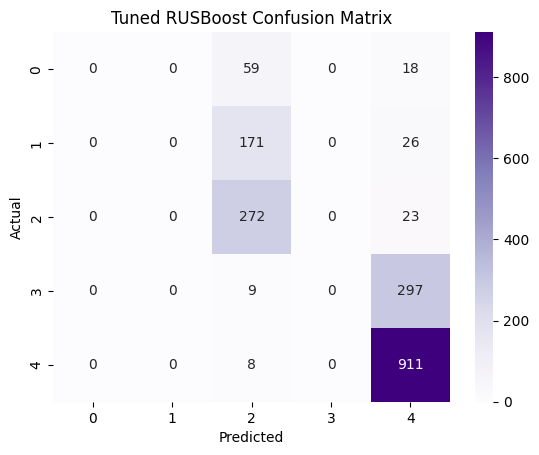

F1 Score For Tuned RUSBoost Classifier :  53.53012092538866
Specificity for Tuned RUSBoost Classifier :  75.98031924664753
NPV for Tuned RUSBoost Classifier :  94.6143354786627
FPR for Tuned RUSBoost Classifier :  24.019680753352475
FNR for Tuned RUSBoost Classifier :  34.05797101449276
ROC-AUC Score for Tuned RUSBoost Classifier :  0.9341782356073933


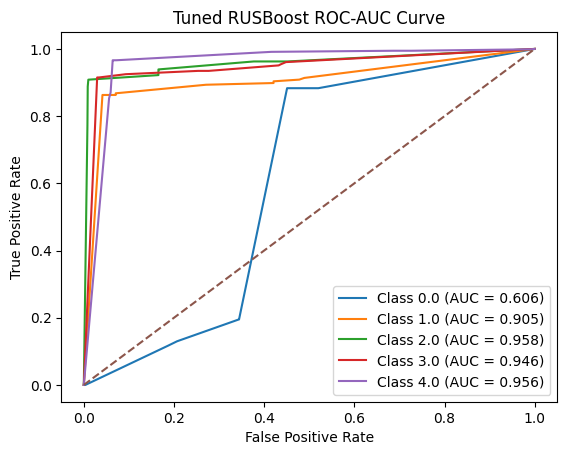

In [62]:
# Accuracy
ac = accuracy_score(ytest, y_pred_rus)
print("Accuracy Score : ", ac * 100)

# Classification Report
print(classification_report(ytest, y_pred_rus))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_rus)

sns.heatmap(cm, annot=True, cmap='Purples', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned RUSBoost Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(ytest, y_pred_rus, average='weighted')
print("F1 Score For Tuned RUSBoost Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_rus = np.average(specificity_list, weights=weights)

npv_rus = np.average(npv_list, weights=weights)

fpr_rus     = np.average(fpr_list, weights=weights)

fnr_rus = np.average(fnr_list, weights=weights)


print("Specificity for Tuned RUSBoost Classifier : ", specificity_rus * 100)
print("NPV for Tuned RUSBoost Classifier : ", npv_rus   * 100)
print("FPR for Tuned RUSBoost Classifier : ", fpr_rus * 100)
print("FNR for Tuned RUSBoost Classifier : ", fnr_rus * 100)


# ROC-AUC

y_prob_rus = rus.predict_proba(xtest)

roc_auc_rus = roc_auc_score(
    ytest,
    y_prob_rus  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Tuned RUSBoost Classifier : ", roc_auc_rus)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_rus[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_rus[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Tuned RUSBoost ROC-AUC Curve")

plt.legend()

plt.show()

## Performing RNN

In [63]:
# Scaling
scaler = StandardScaler()

xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

# ANN
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

# Training
ann.fit(xtrain_scaled, ytrain)

# Training Score
print("Training Score : ", ann.score(xtrain_scaled, ytrain) * 100)

# Testing Score
print("Testing Score : ", ann.score(xtest_scaled, ytest) * 100)

# Prediction
y_pred_ann = ann.predict(xtest_scaled)

Training Score :  100.0
Testing Score :  73.91304347826086


Accuracy Score :  73.91304347826086
              precision    recall  f1-score   support

         0.0       0.38      0.30      0.33        77
         1.0       0.53      0.54      0.54       197
         2.0       0.60      0.57      0.58       295
         3.0       0.59      0.58      0.58       306
         4.0       0.90      0.92      0.91       919

    accuracy                           0.74      1794
   macro avg       0.60      0.58      0.59      1794
weighted avg       0.73      0.74      0.74      1794



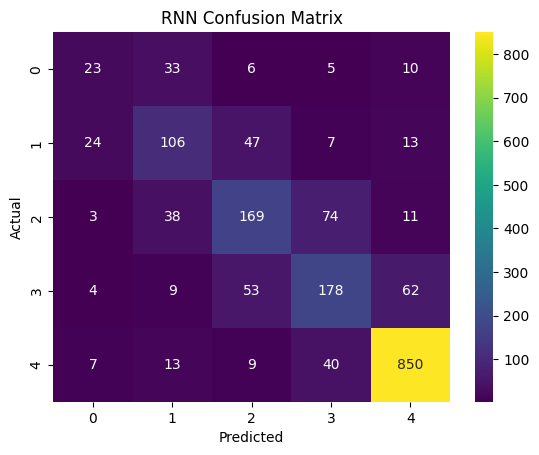

F1 Score For Tuned RNN Classifier :  73.55741347710838
Specificity for Tuned RNN Classifier :  90.9394234241914
NPV for Tuned RNN Classifier :  92.234165496369
FPR for Tuned RNN Classifier :  9.060576575808584
FNR for Tuned RNN Classifier :  26.08695652173913
ROC-AUC Score for Tuned RNN Classifier :  0.9368714722521253


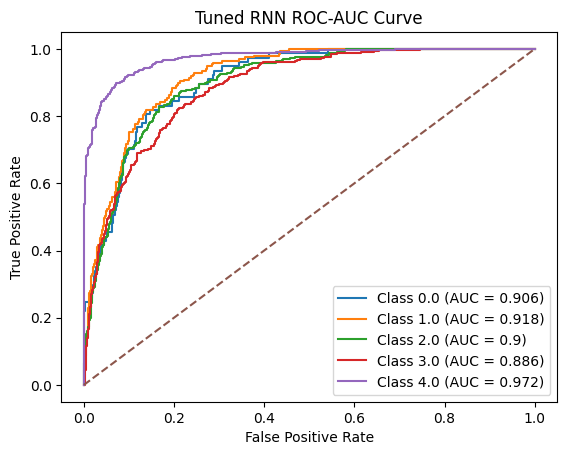

In [64]:
# Accuracy
print("Accuracy Score : ", accuracy_score(ytest, y_pred_ann) * 100)

# Classification Report
print(classification_report(ytest, y_pred_ann))

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_ann)

sns.heatmap(cm, annot=True, cmap='viridis', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(ytest, y_pred_ann, average='weighted')
print("F1 Score For Tuned RNN Classifier : ", f1 * 100)


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_ann = np.average(specificity_list, weights=weights)

npv_ann = np.average(npv_list, weights=weights)

fpr_ann     = np.average(fpr_list, weights=weights)

fnr_ann = np.average(fnr_list, weights=weights)


print("Specificity for Tuned RNN Classifier : ", specificity_ann * 100)
print("NPV for Tuned RNN Classifier : ", npv_ann   * 100)
print("FPR for Tuned RNN Classifier : ", fpr_ann * 100)
print("FNR for Tuned RNN Classifier : ", fnr_ann * 100)


# ROC-AUC

y_prob_ann = ann.predict_proba(xtest_scaled)

roc_auc_ann = roc_auc_score(
    ytest,
    y_prob_ann  ,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for Tuned RNN Classifier : ", roc_auc_ann)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_ann[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_ann[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Tuned RNN ROC-AUC Curve")

plt.legend()

plt.show()

